# 05 — PlantVillage Detection Model Comparison

Final comparison of:

- YOLOv8n
- YOLOv8s
- YOLO11n

**Primary ranking metric:** mAP@0.50:0.95

No GPU is required.

## Before Run All

Collect the lightweight `results/` folder for all three completed experiments into one Google Drive:

```text
MyDrive/PlantVillage_Detection/
└── experiments/
    ├── YOLOv8n/
    │   └── results/
    ├── YOLOv8s/
    │   └── results/
    └── YOLO11n/
        └── results/
```

The `.pt` checkpoint files are not required for this comparison notebook.


# STEP 1 — Imports

In [3]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# STEP 2 — Mount Google Drive

In [4]:
from google.colab import drive

drive.mount("/content/drive")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/PlantVillage_Detection"
)

EXPERIMENTS_DIR = (
    PROJECT_DIR /
    "experiments"
)

COMPARISON_DIR = (
    EXPERIMENTS_DIR /
    "Model_Comparison"
)

COMPARISON_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project:", PROJECT_DIR)
print("Comparison output:", COMPARISON_DIR)


Mounted at /content/drive
Project: /content/drive/MyDrive/PlantVillage_Detection
Comparison output: /content/drive/MyDrive/PlantVillage_Detection/experiments/Model_Comparison


# STEP 3 — Define Result Paths

In [5]:
MODEL_DIRS = {
    "YOLOv8n":
        EXPERIMENTS_DIR / "YOLOv8n",

    "YOLOv8s":
        EXPERIMENTS_DIR / "YOLOv8s",

    "YOLO11n":
        EXPERIMENTS_DIR / "YOLO11n",
}


required_files = {
    model_name: {
        "metrics":
            model_dir /
            "results" /
            "test_metrics.json",

        "per_class":
            model_dir /
            "results" /
            "per_class_test_metrics.csv",

        "summary":
            model_dir /
            "results" /
            "experiment_summary.json",

        "config":
            model_dir /
            "results" /
            "experiment_config.json",
    }

    for model_name, model_dir
    in MODEL_DIRS.items()
}


for model_name, paths in required_files.items():

    print("\n", model_name)

    for key, path in paths.items():

        exists = path.exists()

        print(
            "✅" if exists else "❌",
            key,
            path
        )

        assert exists, (
            f"Missing {key} for {model_name}: {path}"
        )



 YOLOv8n
✅ metrics /content/drive/MyDrive/PlantVillage_Detection/experiments/YOLOv8n/results/test_metrics.json
✅ per_class /content/drive/MyDrive/PlantVillage_Detection/experiments/YOLOv8n/results/per_class_test_metrics.csv
✅ summary /content/drive/MyDrive/PlantVillage_Detection/experiments/YOLOv8n/results/experiment_summary.json
✅ config /content/drive/MyDrive/PlantVillage_Detection/experiments/YOLOv8n/results/experiment_config.json

 YOLOv8s
✅ metrics /content/drive/MyDrive/PlantVillage_Detection/experiments/YOLOv8s/results/test_metrics.json
✅ per_class /content/drive/MyDrive/PlantVillage_Detection/experiments/YOLOv8s/results/per_class_test_metrics.csv
✅ summary /content/drive/MyDrive/PlantVillage_Detection/experiments/YOLOv8s/results/experiment_summary.json
✅ config /content/drive/MyDrive/PlantVillage_Detection/experiments/YOLOv8s/results/experiment_config.json

 YOLO11n
✅ metrics /content/drive/MyDrive/PlantVillage_Detection/experiments/YOLO11n/results/test_metrics.json
✅ per_clas

# STEP 4 — Load All Final Results

In [6]:
metrics = {}
per_class = {}
summaries = {}
configs = {}


for model_name, paths in required_files.items():

    with open(
        paths["metrics"],
        "r"
    ) as f:

        metrics[
            model_name
        ] = json.load(f)


    per_class[
        model_name
    ] = pd.read_csv(
        paths["per_class"]
    )


    with open(
        paths["summary"],
        "r"
    ) as f:

        summaries[
            model_name
        ] = json.load(f)


    with open(
        paths["config"],
        "r"
    ) as f:

        configs[
            model_name
        ] = json.load(f)


print(
    "✅ All three completed experiments loaded."
)


✅ All three completed experiments loaded.


# STEP 5 — Build Final Comparison Table

In [7]:
rows = []


for model_name in [
    "YOLOv8n",
    "YOLOv8s",
    "YOLO11n"
]:

    m = metrics[
        model_name
    ]

    rows.append({
        "Model":
            model_name,

        "Precision":
            float(
                m["precision"]
            ),

        "Recall":
            float(
                m["recall"]
            ),

        "F1":
            float(
                m["f1"]
            ),

        "mAP50":
            float(
                m["map50"]
            ),

        "mAP50-95":
            float(
                m["map50_95"]
            ),

        "Test Images":
            int(
                m.get(
                    "test_images",
                    5296
                )
            ),

        "Image Size":
            int(
                m.get(
                    "image_size",
                    configs[
                        model_name
                    ].get(
                        "image_size",
                        320
                    )
                )
            ),

        "Batch Size":
            int(
                m.get(
                    "batch_size",
                    configs[
                        model_name
                    ].get(
                        "batch_size",
                        16
                    )
                )
            ),
    })


comparison_df = pd.DataFrame(
    rows
)


comparison_df[
    "mAP50-95 Rank"
] = (
    comparison_df[
        "mAP50-95"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)


comparison_df = (
    comparison_df
    .sort_values(
        "mAP50-95",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


display(
    comparison_df.style.format({
        "Precision":
            "{:.6f}",

        "Recall":
            "{:.6f}",

        "F1":
            "{:.6f}",

        "mAP50":
            "{:.6f}",

        "mAP50-95":
            "{:.6f}",
    })
)


,Model,Precision,Recall,F1,mAP50,mAP50-95,Test Images,Image Size,Batch Size,mAP50-95 Rank
0,YOLOv8s,0.994737,0.995709,0.995223,0.994231,0.983002,5296,320,16,1
1,YOLOv8n,0.992832,0.991846,0.992339,0.994014,0.981625,5296,320,16,2
2,YOLO11n,0.993128,0.991207,0.992167,0.993787,0.978832,5296,320,16,3


# STEP 6 — Identify the Best Observed Model

In [8]:
best_row = (
    comparison_df.iloc[
        0
    ]
)


best_model = (
    best_row[
        "Model"
    ]
)


print(
    "Best observed model by mAP50-95:",
    best_model
)

print(
    "mAP50-95:",
    f"{best_row['mAP50-95']:.6f}"
)

print(
    "mAP50:",
    f"{best_row['mAP50']:.6f}"
)

print(
    "F1:",
    f"{best_row['F1']:.6f}"
)


Best observed model by mAP50-95: YOLOv8s
mAP50-95: 0.983002
mAP50: 0.994231
F1: 0.995223


# STEP 7 — Compute Performance Gaps

In [9]:
best_map = (
    comparison_df[
        "mAP50-95"
    ].max()
)


gap_df = comparison_df[
    [
        "Model",
        "mAP50-95",
        "mAP50",
        "F1"
    ]
].copy()


gap_df[
    "mAP50-95 Gap vs Best"
] = (
    best_map
    -
    gap_df[
        "mAP50-95"
    ]
)


display(
    gap_df.style.format({
        "mAP50-95":
            "{:.6f}",

        "mAP50":
            "{:.6f}",

        "F1":
            "{:.6f}",

        "mAP50-95 Gap vs Best":
            "{:.6f}",
    })
)


,Model,mAP50-95,mAP50,F1,mAP50-95 Gap vs Best
0,YOLOv8s,0.983002,0.994231,0.995223,0.000000
1,YOLOv8n,0.981625,0.994014,0.992339,0.001378
2,YOLO11n,0.978832,0.993787,0.992167,0.004170


# STEP 8 — Plot Overall Detection Metrics

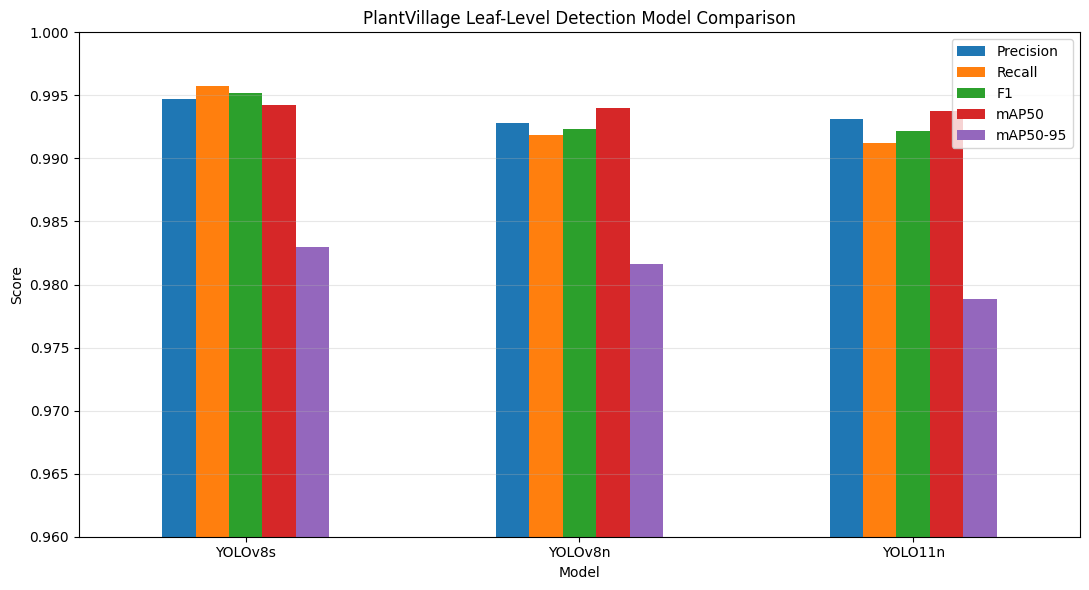

Saved: /content/drive/MyDrive/PlantVillage_Detection/experiments/Model_Comparison/overall_detection_metrics_comparison.png


In [10]:
plot_df = (
    comparison_df
    .set_index(
        "Model"
    )
)


ax = plot_df[
    [
        "Precision",
        "Recall",
        "F1",
        "mAP50",
        "mAP50-95"
    ]
].plot(
    kind="bar",
    figsize=(11, 6)
)


ax.set_ylabel(
    "Score"
)

ax.set_title(
    "PlantVillage Leaf-Level Detection Model Comparison"
)

ax.set_ylim(
    0.96,
    1.0
)

ax.grid(
    axis="y",
    alpha=0.3
)

plt.xticks(
    rotation=0
)

plt.tight_layout()


OVERALL_METRICS_FIG = (
    COMPARISON_DIR /
    "overall_detection_metrics_comparison.png"
)


plt.savefig(
    OVERALL_METRICS_FIG,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    OVERALL_METRICS_FIG
)


# STEP 9 — Plot mAP50 and mAP50-95

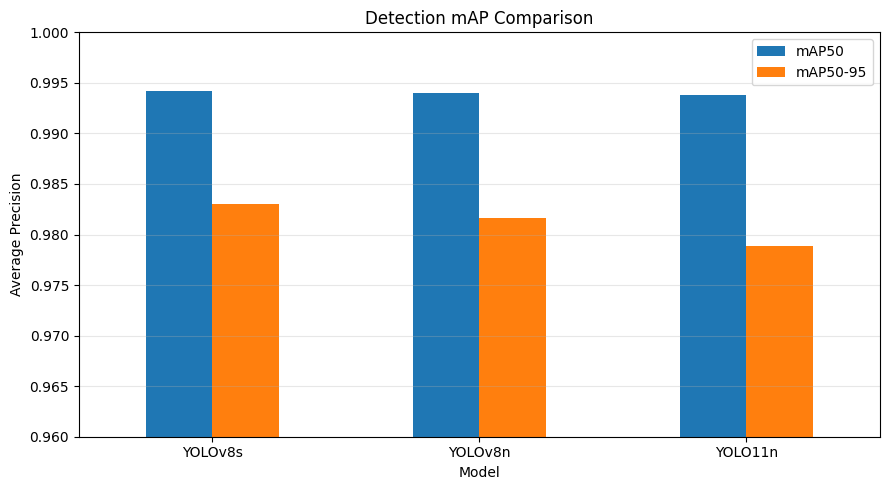

Saved: /content/drive/MyDrive/PlantVillage_Detection/experiments/Model_Comparison/map_comparison.png


In [11]:
ax = plot_df[
    [
        "mAP50",
        "mAP50-95"
    ]
].plot(
    kind="bar",
    figsize=(9, 5)
)


ax.set_ylabel(
    "Average Precision"
)

ax.set_title(
    "Detection mAP Comparison"
)

ax.set_ylim(
    0.96,
    1.0
)

ax.grid(
    axis="y",
    alpha=0.3
)

plt.xticks(
    rotation=0
)

plt.tight_layout()


MAP_FIG = (
    COMPARISON_DIR /
    "map_comparison.png"
)


plt.savefig(
    MAP_FIG,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    MAP_FIG
)


# STEP 10 — Merge Per-Class Test Metrics

In [12]:
per_class_frames = []


for model_name, df in per_class.items():

    temp = df.copy()


    temp = temp.rename(
        columns={
            "map50_95":
                f"{model_name}_mAP50-95",

            "map50":
                f"{model_name}_mAP50",

            "precision":
                f"{model_name}_Precision",

            "recall":
                f"{model_name}_Recall",

            "f1":
                f"{model_name}_F1",
        }
    )


    keep_cols = [
        c
        for c in temp.columns
        if (
            c in [
                "class_id",
                "class_name"
            ]
            or
            c.startswith(
                model_name
            )
        )
    ]


    per_class_frames.append(
        temp[
            keep_cols
        ]
    )


per_class_comparison = (
    per_class_frames[
        0
    ]
)


for next_df in per_class_frames[
    1:
]:

    per_class_comparison = (
        per_class_comparison
        .merge(
            next_df,
            on=[
                "class_id",
                "class_name"
            ],
            how="inner"
        )
    )


print(
    "Classes compared:",
    len(
        per_class_comparison
    )
)


assert len(
    per_class_comparison
) == 38


display(
    per_class_comparison.head()
)


Classes compared: 38


,class_id,class_name,YOLOv8n_mAP50-95,YOLOv8n_Precision,YOLOv8n_Recall,YOLOv8n_F1,YOLOv8n_mAP50,YOLOv8s_mAP50-95,YOLOv8s_Precision,YOLOv8s_Recall,YOLOv8s_F1,YOLOv8s_mAP50,YOLO11n_mAP50-95,YOLO11n_Precision,YOLO11n_Recall,YOLO11n_F1,YOLO11n_mAP50
0,0,Apple___Apple_scab,0.984833,0.984148,0.985487,0.984817,0.994375,0.986698,1.000000,0.986876,0.993394,0.995,0.982921,1.000000,0.971939,0.985770,0.995000
1,1,Apple___Black_rot,0.989257,0.994844,1.000000,0.997415,0.995000,0.993613,0.996415,1.000000,0.998205,0.995,0.993016,0.996743,1.000000,0.998369,0.995000
2,2,Apple___Cedar_apple_rust,0.990481,0.994240,1.000000,0.997112,0.995000,0.982732,0.990285,1.000000,0.995119,0.995,0.972615,0.994948,1.000000,0.997468,0.995000
3,3,Apple___healthy,0.935735,0.993257,0.993939,0.993598,0.993121,0.967019,1.000000,0.992701,0.996337,0.995,0.962296,0.992409,0.987879,0.990139,0.994699
4,4,Blueberry___healthy,0.986188,1.000000,0.998120,0.999059,0.995000,0.986997,0.999390,1.000000,0.999695,0.995,0.986403,1.000000,0.997507,0.998752,0.995000


# STEP 11 — Per-Class mAP50-95 Plot

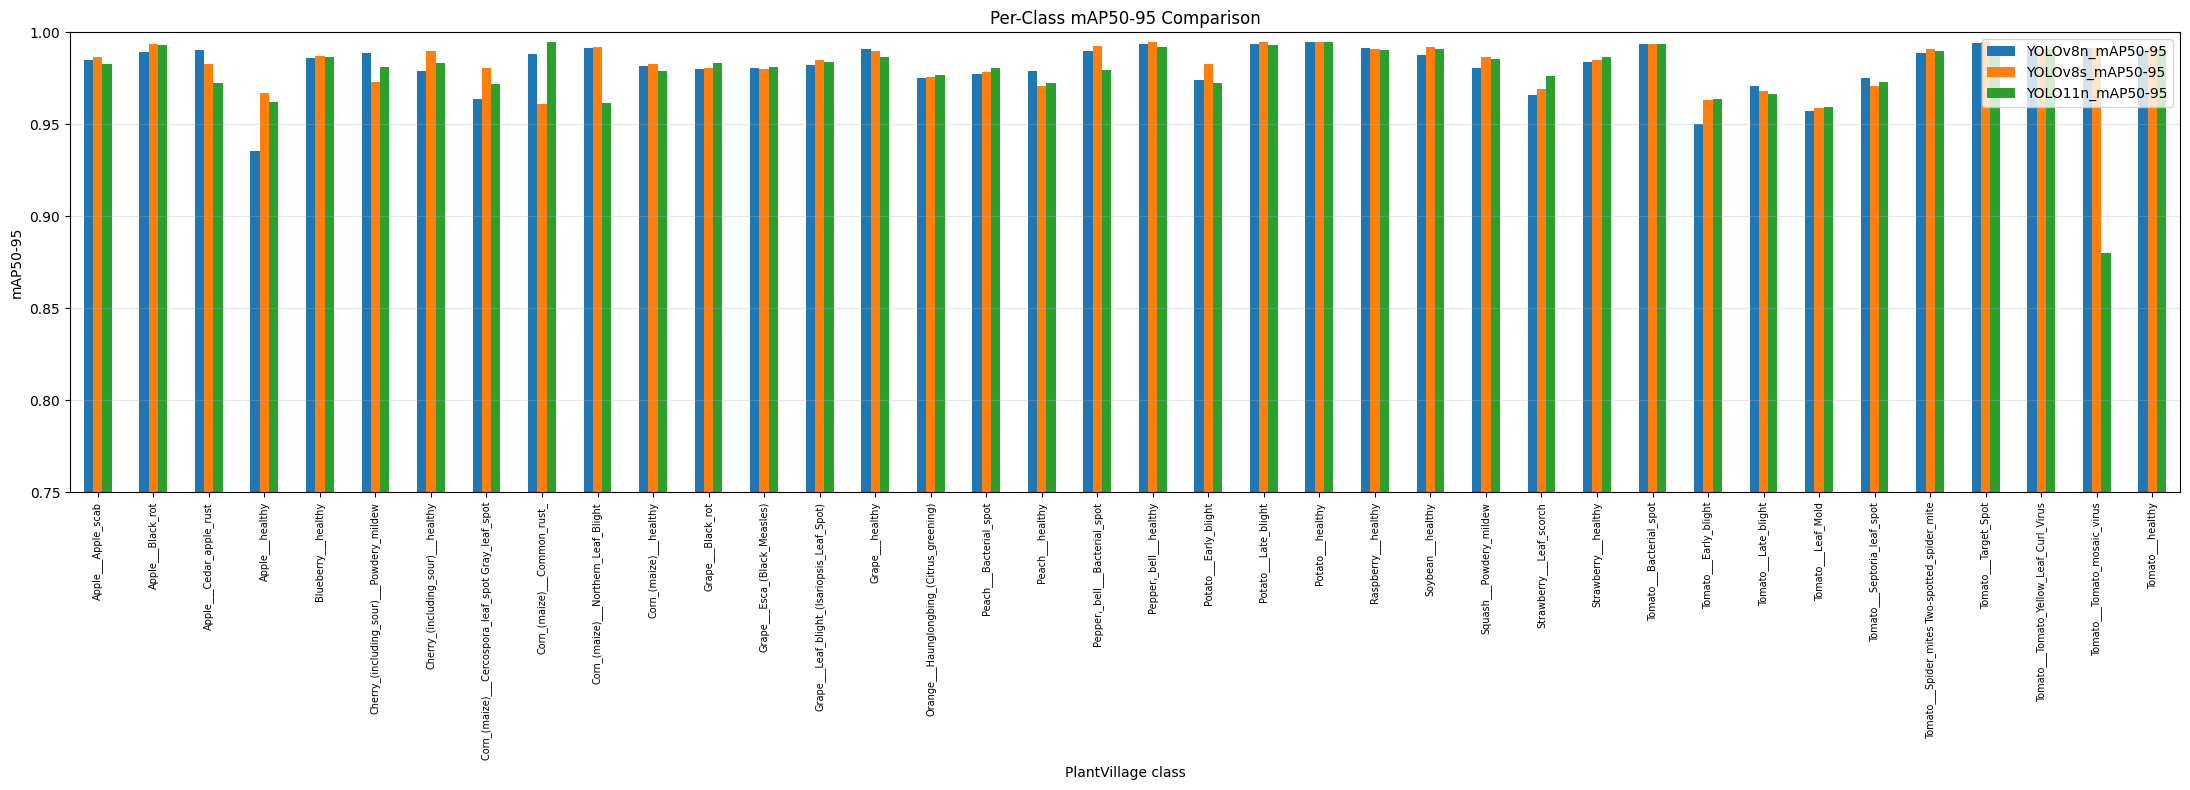

Saved: /content/drive/MyDrive/PlantVillage_Detection/experiments/Model_Comparison/per_class_map50_95_comparison.png


In [13]:
map_cols = [
    "YOLOv8n_mAP50-95",
    "YOLOv8s_mAP50-95",
    "YOLO11n_mAP50-95"
]


per_class_plot = (
    per_class_comparison
    .set_index(
        "class_name"
    )[
        map_cols
    ]
)


ax = per_class_plot.plot(
    kind="bar",
    figsize=(22, 8)
)


ax.set_ylabel(
    "mAP50-95"
)

ax.set_xlabel(
    "PlantVillage class"
)

ax.set_title(
    "Per-Class mAP50-95 Comparison"
)

ax.set_ylim(
    0.75,
    1.0
)

ax.grid(
    axis="y",
    alpha=0.3
)

plt.xticks(
    rotation=90,
    fontsize=7
)

plt.tight_layout()


PER_CLASS_FIG = (
    COMPARISON_DIR /
    "per_class_map50_95_comparison.png"
)


plt.savefig(
    PER_CLASS_FIG,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    PER_CLASS_FIG
)


# STEP 12 — Identify Hardest Classes

In [14]:
best_col = (
    f"{best_model}_mAP50-95"
)


hardest_classes = (
    per_class_comparison[
        [
            "class_id",
            "class_name",
            best_col
        ]
    ]
    .sort_values(
        best_col,
        ascending=True
    )
    .head(
        10
    )
    .reset_index(
        drop=True
    )
)


print(
    f"10 lowest mAP50-95 classes for {best_model}:"
)


display(
    hardest_classes.style.format({
        best_col:
            "{:.6f}"
    })
)


10 lowest mAP50-95 classes for YOLOv8s:


,class_id,class_name,YOLOv8s_mAP50-95
0,31,Tomato___Leaf_Mold,0.958714
1,8,Corn_(maize)___Common_rust_,0.961032
2,29,Tomato___Early_blight,0.963087
3,3,Apple___healthy,0.967019
4,30,Tomato___Late_blight,0.967891
5,26,Strawberry___Leaf_scorch,0.969085
6,17,Peach___healthy,0.970569
7,32,Tomato___Septoria_leaf_spot,0.970882
8,5,Cherry_(including_sour)___Powdery_mildew,0.973157
9,15,Orange___Haunglongbing_(Citrus_greening),0.975901


# STEP 13 — Save Final Comparison Files

In [15]:
COMPARISON_CSV = (
    COMPARISON_DIR /
    "detection_model_comparison.csv"
)


COMPARISON_JSON = (
    COMPARISON_DIR /
    "detection_model_comparison.json"
)


PER_CLASS_CSV = (
    COMPARISON_DIR /
    "per_class_detection_comparison.csv"
)


HARDEST_CLASSES_CSV = (
    COMPARISON_DIR /
    "hardest_classes_by_best_model.csv"
)


comparison_df.to_csv(
    COMPARISON_CSV,
    index=False
)


per_class_comparison.to_csv(
    PER_CLASS_CSV,
    index=False
)


hardest_classes.to_csv(
    HARDEST_CLASSES_CSV,
    index=False
)


comparison_payload = {
    "primary_ranking_metric":
        "mAP50-95",

    "best_observed_model":
        best_model,

    "models":
        comparison_df.to_dict(
            orient="records"
        ),

    "interpretation_note":
        (
            "All three models used the same final "
            "PlantVillage detection manifest, fixed split, "
            "COCO-to-PlantDoc-to-PlantVillage transfer "
            "pipeline, image size, batch size, optimizer "
            "family, and evaluation protocol."
        ),

    "task_scope":
        (
            "Whole-leaf localization with disease-class "
            "prediction; not lesion-level detection."
        ),
}


with open(
    COMPARISON_JSON,
    "w"
) as f:

    json.dump(
        comparison_payload,
        f,
        indent=4
    )


print(
    "Saved:",
    COMPARISON_CSV
)

print(
    "Saved:",
    COMPARISON_JSON
)

print(
    "Saved:",
    PER_CLASS_CSV
)

print(
    "Saved:",
    HARDEST_CLASSES_CSV
)


Saved: /content/drive/MyDrive/PlantVillage_Detection/experiments/Model_Comparison/detection_model_comparison.csv
Saved: /content/drive/MyDrive/PlantVillage_Detection/experiments/Model_Comparison/detection_model_comparison.json
Saved: /content/drive/MyDrive/PlantVillage_Detection/experiments/Model_Comparison/per_class_detection_comparison.csv
Saved: /content/drive/MyDrive/PlantVillage_Detection/experiments/Model_Comparison/hardest_classes_by_best_model.csv


# STEP 14 — Generate Paper-Ready LaTeX Table

In [16]:
table_df = comparison_df[
    [
        "Model",
        "Precision",
        "Recall",
        "F1",
        "mAP50",
        "mAP50-95"
    ]
].copy()


latex_table = table_df.to_latex(
    index=False,
    float_format=lambda x: f"{x:.6f}",
    caption=(
        "Test-set performance of the three "
        "leaf-level disease detection models."
    ),
    label="tab:detection_comparison"
)


LATEX_TABLE_PATH = (
    COMPARISON_DIR /
    "detection_comparison_table.tex"
)


LATEX_TABLE_PATH.write_text(
    latex_table,
    encoding="utf-8"
)


print(
    latex_table
)

print(
    "\nSaved:",
    LATEX_TABLE_PATH
)


\begin{table}
\caption{Test-set performance of the three leaf-level disease detection models.}
\label{tab:detection_comparison}
\begin{tabular}{lrrrrr}
\toprule
Model & Precision & Recall & F1 & mAP50 & mAP50-95 \\
\midrule
YOLOv8s & 0.994737 & 0.995709 & 0.995223 & 0.994231 & 0.983002 \\
YOLOv8n & 0.992832 & 0.991846 & 0.992339 & 0.994014 & 0.981625 \\
YOLO11n & 0.993128 & 0.991207 & 0.992167 & 0.993787 & 0.978832 \\
\bottomrule
\end{tabular}
\end{table}


Saved: /content/drive/MyDrive/PlantVillage_Detection/experiments/Model_Comparison/detection_comparison_table.tex


# STEP 15 — Print Final Interpretation

In [17]:
print(
    "=" * 72
)

print(
    "FINAL DETECTION MODEL COMPARISON"
)

print(
    "=" * 72
)


for rank, row in comparison_df.iterrows():

    print(
        f"{rank + 1}. "
        f"{row['Model']} | "
        f"mAP50-95={row['mAP50-95']:.6f} | "
        f"mAP50={row['mAP50']:.6f} | "
        f"F1={row['F1']:.6f}"
    )


print()


print(
    "Best observed model:",
    best_model
)


print(
    "\nInterpretation: report the observed ranking, "
    "but keep the task scope explicit: these are "
    "mask-derived whole-leaf bounding boxes on the "
    "controlled PlantVillage setting, not lesion-level "
    "bounding-box detection."
)


FINAL DETECTION MODEL COMPARISON
1. YOLOv8s | mAP50-95=0.983002 | mAP50=0.994231 | F1=0.995223
2. YOLOv8n | mAP50-95=0.981625 | mAP50=0.994014 | F1=0.992339
3. YOLO11n | mAP50-95=0.978832 | mAP50=0.993787 | F1=0.992167

Best observed model: YOLOv8s

Interpretation: report the observed ranking, but keep the task scope explicit: these are mask-derived whole-leaf bounding boxes on the controlled PlantVillage setting, not lesion-level bounding-box detection.
